### Quiz(data/burn_out_train.csv)
* 모든 사람이 팬데믹(세계적 대유행) 상항으로 고통받고 있는 요즘, 정신 건강을 유지하기가 정말 어려워지고 있다.
* 익명의 설문 조사에 따르면 전 세계적으로 약 4억5천만 명의 사람들이 건강 악화와 장애의 주요 원인 중 하나가 될 수 있는 정신 장애를 안고 살고 있다.
* 현재의 전염병 상황을 기반으로 회사에서 일하는 직원들의 능률이 떨어지는 이유가 무엇인지 알아보자
* 제공된 다양한 조건에 따라 직원의 능률에 어떤 영향을 받는지 알아보자
>
* 1. 어떤 경우에 Burn Rate과 연관이 있는지 확인하고 최적의 모델을 찾으시오.
    - ( 결측치, 문자열, 이상치, 중복값, 시계열, 스케일러, 하이퍼파라미터, 변수 선택 )

### 컬럼
* Employee ID: 사원별로 부여된 고유 ID (예: fffe390032003000 )
* Date of Joining: 직원이 조직에 합류한 날짜-시간(예: 2008-12-30 )
* Gender: 사원의 성별( 남(Male : 1)/여(Female : 0) )
* Company Type: 직원이 근무하는 회사의 유형( 서비스(Service : 1)/제품(Product : 0) )
* WFH Setup Available: 직원이 재택근무 시설을 이용할 수 있습니까( Yes(1) / No(0) )
* Designation: 회사에서 일하는 직원의 직책.
	- [0.0, 5.0] 범위에서 클수록 높은 직책입니다.
* Resource Allocation: 작업을 위해 직원에게 할당된 자원의 양, 즉. 근무 시간 수.
	- [1.0, 10.0] 범위 (높을수록 더 많은 리소스를 의미)
* Mental Fatigue Score: 직원이 겪고 있는 정신적 피로 정도.
	- [0.0, 10.0] 범위 에서 0.0은 피로가 없음을 의미하고 10.0은 완전히 피로함을 의미합니다.
* Burn Rate: 근무 중 Bur out의 비율을 말하는 각 직원에 대해 예측해야 하는 값입니다.
	- [0.0, 1.0] 의 범위 에서 값이 높을수록 번아웃됩니다.

### 데이터 전처리

In [13]:
import pandas as pd
df_train = pd.read_csv('../data_set/6.회귀/burn_out_train.csv')
print(df_train.shape)
df_train.head()

(22750, 9)


,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


#### 결측치
* 결측치 확인

In [14]:
df_train.isnull().sum()

Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64

* 결측치 삭제

In [15]:
df_train.dropna(inplace=True)
df_train.isnull().sum()

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
Burn Rate               0
dtype: int64

#### 문자열 처리

In [16]:
df_train.dtypes

Employee ID              object
Date of Joining          object
Gender                   object
Company Type             object
WFH Setup Available      object
Designation             float64
Resource Allocation     float64
Mental Fatigue Score    float64
Burn Rate               float64
dtype: object

* 문자열 데이터 확인

In [17]:
li = [ 'Gender','Company Type','WFH Setup Available','Date of Joining']
for i in li:
    print(i,"=>",df_train[i].unique())

Gender => ['Female' 'Male']
Company Type => ['Service' 'Product']
WFH Setup Available => ['No' 'Yes']
Date of Joining => ['2008-09-30' '2008-11-30' '2008-11-03' '2008-07-24' '2008-11-26'
 '2008-01-02' '2008-10-31' '2008-03-16' '2008-05-12' '2008-05-14'
 '2008-02-03' '2008-03-17' '2008-03-28' '2008-05-29' '2008-08-31'
 '2008-01-15' '2008-05-04' '2008-10-11' '2008-09-18' '2008-09-16'
 '2008-12-16' '2008-03-10' '2008-05-03' '2008-08-04' '2008-07-31'
 '2008-06-17' '2008-04-28' '2008-10-30' '2008-06-22' '2008-02-18'
 '2008-06-24' '2008-12-08' '2008-04-11' '2008-08-28' '2008-03-21'
 '2008-07-22' '2008-01-23' '2008-10-09' '2008-09-10' '2008-05-26'
 '2008-12-22' '2008-04-08' '2008-02-25' '2008-01-08' '2008-11-20'
 '2008-09-11' '2008-06-11' '2008-02-28' '2008-08-20' '2008-10-18'
 '2008-08-14' '2008-07-17' '2008-07-05' '2008-02-04' '2008-08-01'
 '2008-05-21' '2008-10-21' '2008-03-19' '2008-09-27' '2008-03-12'
 '2008-05-20' '2008-09-17' '2008-02-13' '2008-09-19' '2008-07-03'
 '2008-10-27' '2008-0

In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_train['Gender_num'] = le.fit_transform(df_train['Gender'])
df_train['Company_Type_num'] = le.fit_transform(df_train['Company Type'])
df_train['WFH_S_Available_num'] = le.fit_transform(df_train['WFH Setup Available'])
print(df_train.dtypes)
df_train

Employee ID              object
Date of Joining          object
Gender                   object
Company Type             object
WFH Setup Available      object
Designation             float64
Resource Allocation     float64
Mental Fatigue Score    float64
Burn Rate               float64
Gender_num                int64
Company_Type_num          int64
WFH_S_Available_num       int64
dtype: object


,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_num,Company_Type_num,WFH_S_Available_num
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16,0,1,0
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36,1,1,1
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20,1,1,1
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52,0,1,0
5,fffe3300350037003500,2008-11-26,Male,Product,Yes,2.0,4.0,3.6,0.29,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
22743,fffe3300390030003600,2008-12-15,Female,Product,Yes,1.0,3.0,6.0,0.48,0,0,1
22744,fffe32003500370033003200,2008-05-27,Male,Product,No,3.0,7.0,6.2,0.54,1,0,0
22746,fffe33003000350031003800,2008-01-19,Female,Product,Yes,3.0,6.0,6.7,0.59,0,0,1
22748,fffe33003300320036003900,2008-01-10,Female,Service,No,2.0,5.0,5.9,0.52,0,1,0


In [19]:
df_train.describe()
# 이전 글에서 각각의 범위가 나왔었다. 이상치 확인결과 그 범위 안의 값들이라 이상치는 없다.
# 

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Gender_num,Company_Type_num,WFH_S_Available_num
count,18590.000000,18590.000000,18590.000000,18590.000000,18590.000000,18590.000000,18590.000000
mean,2.179398,4.486552,5.732173,0.452444,0.475686,0.654868,0.539537
std,1.133148,2.044848,1.920547,0.197848,0.499422,0.475424,0.498448
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.320000,0.000000,0.000000,0.000000
50%,2.000000,4.000000,5.900000,0.450000,0.000000,1.000000,1.000000
75%,3.000000,6.000000,7.100000,0.590000,1.000000,1.000000,1.000000
max,5.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000


#### 중복값

In [20]:
df_train.duplicated().sum()

np.int64(0)

#### 시계열

In [21]:
df_train['new_date'] = pd.to_datetime( df_train['Date of Joining'] )

In [22]:
df_train['year'] = df_train['new_date'].dt.year
df_train['month'] = df_train['new_date'].dt.month
df_train['day'] = df_train['new_date'].dt.day
df_train.head().T

,0,1,3,4,5
Employee ID,fffe32003000360033003200,fffe3700360033003500,fffe32003400380032003900,fffe31003900340031003600,fffe3300350037003500
Date of Joining,2008-09-30,2008-11-30,2008-11-03,2008-07-24,2008-11-26
Gender,Female,Male,Male,Female,Male
Company Type,Service,Service,Service,Service,Product
WFH Setup Available,No,Yes,Yes,No,Yes
Designation,2.0,1.0,1.0,3.0,2.0
Resource Allocation,3.0,2.0,1.0,7.0,4.0
Mental Fatigue Score,3.8,5.0,2.6,6.9,3.6
Burn Rate,0.16,0.36,0.2,0.52,0.29
Gender_num,0,1,1,0,1


### 탐색적 데이터 분석(ERD)

#### 상관계수

<Axes: >

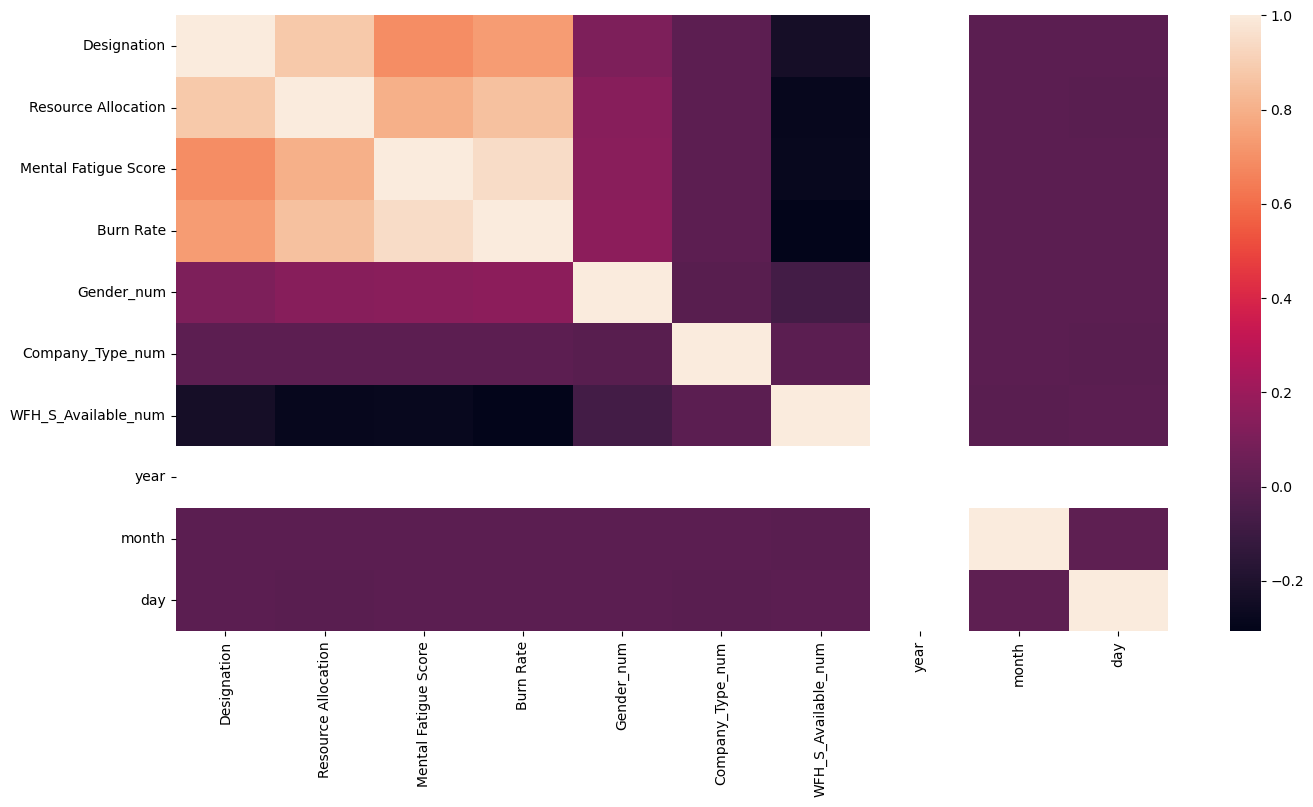

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax1 = plt.subplots()
fig.set_size_inches(16, 8)
sns.heatmap(df_train.corr(numeric_only=True), ax=ax1)

In [24]:
df_train['year'].unique()
# 년도는 2008년 하나밖에 없어 탐색적 데이터 분석에서는 해당 데이터를 뺄 것이다.

array([2008], dtype=int32)

* 월별 남/녀 burn rate(근무중 번아웃의 비율) 확인

<Axes: xlabel='month', ylabel='Burn Rate'>

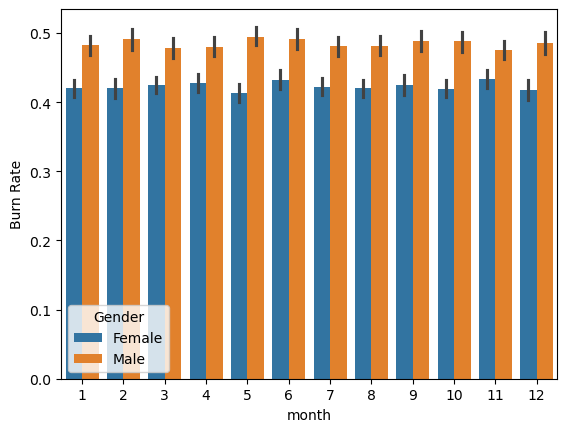

In [25]:
# 특정 월에 더 스트레스를 받거나 하는 큰 차이는 없다
# 그대신 여성보다 남성이 더 스트레스를 많이 받는다는 것을 알 수 있다.
# 그렇다고 하는건 직급 또는 일하는 양이 여성보다 남성이 더 많을 가능성이 있다.
# 혹은 남성의 멘탈이 많이 약할 수 있다고 볼 수 있다
sns.barplot(data=df_train, x='month', y='Burn Rate', hue='Gender')

* 위의 결과에서 남성과 여성의 직급 또는 일하는 시간이 많을 수 있다고 짐작했으니 확인해 보도록 하자
* Designation: 회사에서 일하는 직원의 직책.
    - [0.0, 5.0] 범위에서 클수록 높은 직책입니다.

<Axes: xlabel='month', ylabel='Designation'>

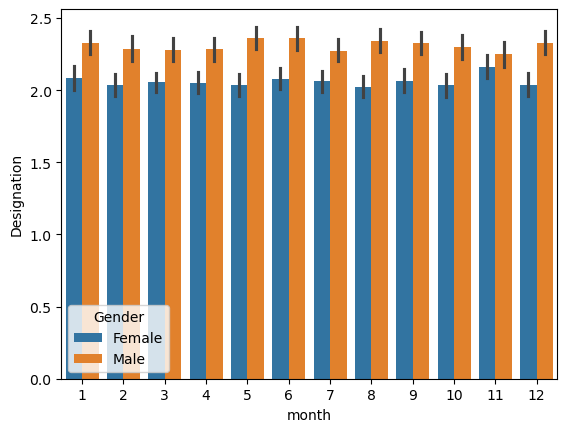

In [26]:
sns.barplot(data=df_train, x='month', y='Designation', hue='Gender')
#확인결과 여성보다 남성의 직급이 높다는 것을 알 수 있다

* 그럼 직책별 일하는 시간을 확인해 보도록 하자
* Resource Allocation: 작업을 위해 직원에게 할당된 자원의 양, 즉. 근무 시간 수.
    - [1.0, 10.0] 범위 (높을수록 더 많은 리소스를 의미)

<Axes: xlabel='Designation', ylabel='Resource Allocation'>

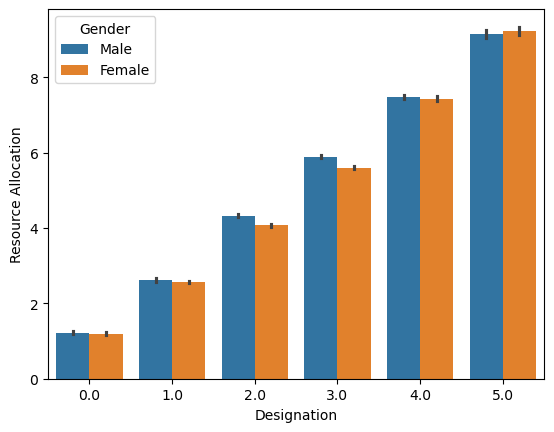

In [27]:
sns.barplot(data=df_train,  x='Designation',y='Resource Allocation', hue='Gender')
# 단순히 위의 내용을 봤을땐 남성이 직책이 높아 일을 많이 하지 않을까 
# 그래서 번아웃이 더 큰가 했는데 그렇지는 않다는 것을 알 수 있다.
# 직책이 높은경우 여성이 남성보다 일을 더 많이 한다는 것을 알 수 있다.
# 지금 상황으로만 봤을 땐 여성보다 남성의 멘탈이 약하지 않을까 생각이 든다

<Axes: xlabel='Resource Allocation', ylabel='Designation'>

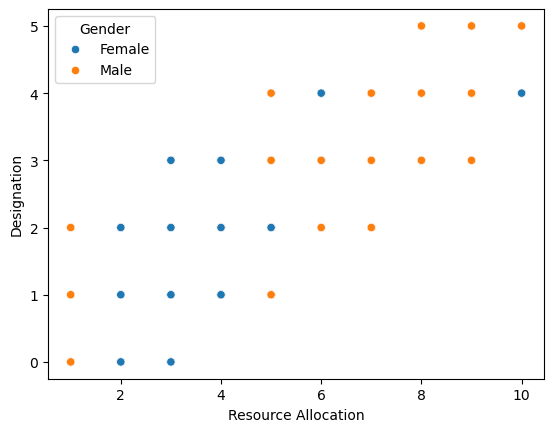

In [28]:
sns.scatterplot(data=df_train, x='Resource Allocation', y='Designation', hue='Gender')
# 우 상향을 한다는 것은 두개가 상관관계가 높다고 볼 수 있다.
# 즉 직책이 높을수록 일하는 시간이 더 많아 스트레스를 더 많이 받는다는 것을 알 수 있다.

* 근무시간에 따른 번아웃

<Axes: xlabel='Resource Allocation', ylabel='Burn Rate'>

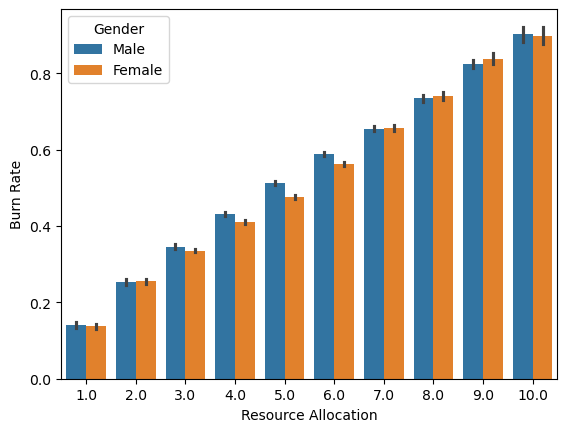

In [29]:
sns.barplot(data=df_train, x='Resource Allocation', y='Burn Rate', hue='Gender')
# 근무시간역시 예상대로 일하는 시간이 많으면 많을 수록 스트레스를 많이 받는다고 나온다.

* 직책이 높을 수록 일을 많이 하나??

<Axes: xlabel='Resource Allocation', ylabel='Designation'>

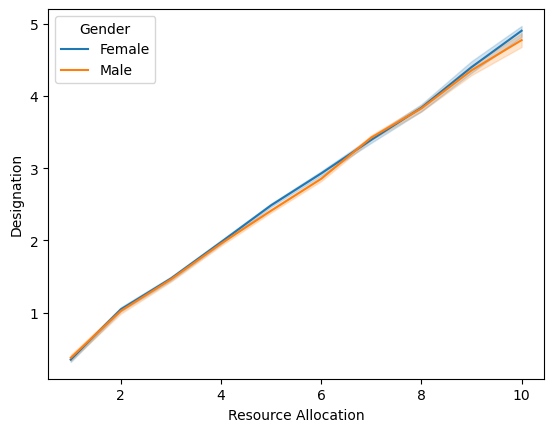

In [30]:
# 위에서 확인한거와 마찬가지로 일하는 시간과 직책과는 상관계수가 높다는 것을 알 수 있다.
sns.lineplot(data = df_train,  x='Resource Allocation', y='Designation', hue='Gender')

* 직업별 차이가 있는가?
* Company Type: 직원이 근무하는 회사의 유형( 서비스(Service : 1)/제품(Product : 0) )

<Axes: xlabel='Company_Type_num', ylabel='Burn Rate'>

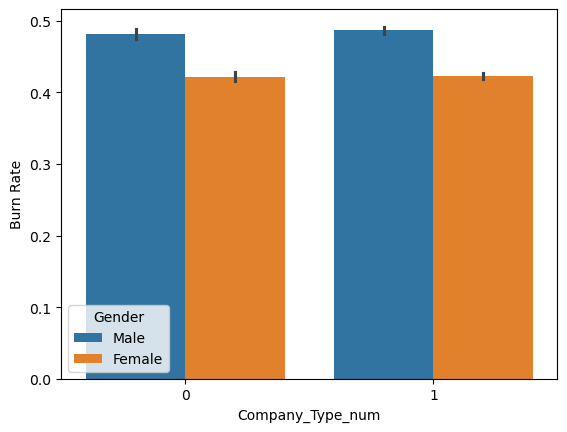

In [31]:
# 직업별 차이가 있나 확인해 봤더니 직업별 차이는 없는거 같다.
sns.barplot(data=df_train, x='Company_Type_num', y='Burn Rate', hue='Gender')

### 모델링

#### train, test셋 분리

In [32]:
# 위에서 봤던 Burn Rate(target)와의 상관관계가 높은것 3개만 추려서 확인해봐도 결과는 비슷하게 나온다
#features = [ 'Designation', 'Resource Allocation', 'Mental Fatigue Score']
# 연도는 2008년 하나라 뺏다
features = [ 'Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Gender_num', 'Company_Type_num',
       'WFH_S_Available_num', 'month', 'day']
label = 'Burn Rate'
# 날짜와 날씨 정보를 이용해 자전거 수요량을 알아 맞추고자 한다.
X, y = df_train[features],df_train[label]

In [33]:
# 선형회귀 모델 생성을 위한 라이브러리 임포트
from sklearn.model_selection import train_test_split

# 학습에 사용할 데이터 준비
# train, test 세트 분리
X_train, X_test, y_train, y_test = train_test_split(df_train[features], df_train[label], test_size=0.3, random_state = 156)

#### KNN 모델

In [34]:
from sklearn.neighbors import KNeighborsRegressor

kn = KNeighborsRegressor()
kn.fit(X_train, y_train)

print('train :',kn.score(X_train, y_train))
print('test :',kn.score(X_test, y_test))

train : 0.9301453530979517
test : 0.8962082080264708


##### 스케일링

In [35]:
from sklearn.preprocessing import MinMaxScaler
minMaxScaler = MinMaxScaler()
minMaxScaler.fit(X_train)

X_train_minMax = minMaxScaler.transform(X_train)
X_test_minMax = minMaxScaler.transform(X_test)

kn.fit(X_train_minMax, y_train)
print('train :',kn.score(X_train_minMax, y_train))
print('test :',kn.score(X_test_minMax, y_test))

train : 0.9204720063578586
test : 0.8820439931292244


##### GridSearchCV

In [36]:
from sklearn.model_selection import GridSearchCV
params={
    'n_neighbors':range(1,11)
}
grid_cv = GridSearchCV(kn, param_grid = params, cv=3, n_jobs= -1)
grid_cv.fit(X_train_minMax, y_train)

print('최적의 하이퍼 파라미터 :', grid_cv.best_params_ )

print('train :',grid_cv.score(X_train_minMax, y_train))
print('test :',grid_cv.score(X_test_minMax, y_test))

최적의 하이퍼 파라미터 : {'n_neighbors': 8}
train : 0.9105684640519021
test : 0.88395607399651


#### SVR 모델

##### 선형모델

In [37]:
from sklearn.svm import SVR
# 선형 모델
svr_linear = SVR(kernel = 'linear')
svr_linear.fit(X_train, y_train)

print('train :',svr_linear.score(X_train, y_train))
print('test :',svr_linear.score(X_test, y_test))

train : 0.9154843295453475
test : 0.9171425663598753


##### 비선형모델

In [38]:
# 비선형 모델
svr_rbf = SVR(kernel = 'rbf')
svr_rbf.fit(X_train_minMax, y_train)

print('train :',svr_rbf.score(X_train_minMax, y_train))
print('test :',svr_rbf.score(X_test_minMax, y_test))

train : 0.9140870669175767
test : 0.913136290468217


##### 스케일링(StandardScaler)

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train_standard = scaler.transform(X_train)
X_test_standard = scaler.transform(X_test)

##### 선형모델 스케일 적용

In [40]:
svr_linear.fit(X_train_standard, y_train)

print('train :', svr_linear.score(X_train_standard, y_train))
print('test :', svr_linear.score(X_test_standard, y_test))

train : 0.9154410272312381
test : 0.9171220014778022


##### 비선형 모델 스케일 적용

In [41]:
svr_rbf.fit(X_train_standard, y_train)

print('train :', svr_rbf.score(X_train_standard, y_train))
print('test :', svr_rbf.score(X_test_standard, y_test))

train : 0.9144173236360233
test : 0.913096155013097


##### GridSearchCV(선형모델)

In [42]:
# 시간이 꽤 걸린다
param_range = [ 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
params = {
    'C':param_range
}

svr = SVR(kernel = 'linear',)

grid_cv = GridSearchCV(svr, param_grid = params, cv=3, n_jobs = -1)

grid_cv.fit(X_train_standard, y_train)

print('최적의 하이퍼 파라미터 :',grid_cv.best_params_ )

print('train :',grid_cv.score(X_train_standard, y_train))
print('test :',grid_cv.score(X_test_standard, y_test))

최적의 하이퍼 파라미터 : {'C': 0.001}
train : 0.9175820094862354
test : 0.9193224164536481


##### GridSearchCV(비선형모델)

In [43]:
# 비선형 모델
param_range = [ 0.001, 0.01, 0.1, 1.0,10.0, 100.0]
param_gamma = [ 0.001, 0.01, 0.1, 1.0, 10.0 ]

params = {
    'C':param_range,
    'gamma':param_gamma
}

svr = SVR(kernel='rbf')

grid_cv = GridSearchCV(svr, param_grid = params, cv=3, n_jobs= -1)
grid_cv.fit(X_train_standard, y_train)

print('최적의 하이퍼 파라미터 :', grid_cv.best_params_ )

print('train :',grid_cv.score(X_train_standard, y_train))
print('test :', grid_cv.score(X_test_standard, y_test))

최적의 하이퍼 파라미터 : {'C': 0.1, 'gamma': 0.01}
train : 0.9187978744030598
test : 0.9198617153772063


#### RandomForest

In [44]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()

rfr.fit(X_train, y_train)

print('train :', rfr.score(X_train, y_train))
print('test :', rfr.score(X_test, y_test))

train : 0.9886090886025616
test : 0.9205071658720656


##### GridSearchCV

In [45]:
# 시간이 꽤 걸린다
params = {
    'n_estimators':range(5,100,10),
    'max_depth': range(4, 11, 2),
    'min_samples_leaf': range(5, 21, 5),
    'min_samples_split': range(4, 21, 4)
}

rfr = RandomForestRegressor()

grid_cv = GridSearchCV(rfr, param_grid = params, cv=3, n_jobs = -1)
grid_cv.fit(X_train, y_train)

print('최적의 하이퍼 파라미터 :', grid_cv.best_params_ )

print('train :', grid_cv.score(X_train, y_train))
print('test :', grid_cv.score(X_test, y_test))

최적의 하이퍼 파라미터 : {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 8, 'n_estimators': 75}
train : 0.9341663772083286
test : 0.928265299493837


#### GBM

In [46]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

print('train :', gbr.score(X_train, y_train))
print('test :', gbr.score(X_test, y_test))

train : 0.9281988433162298
test : 0.9277859363651296


##### GridSearchCV

In [47]:
# 시간이 조금 걸린다
import numpy as np
params = {
    'learning_rate':[0.1,0.3,0.5,0.7,0.9],
    'n_estimators' : [100,300,500,700],
    'subsample' : np.arange(0.1, 1, 0.2) 
}

gbr = GradientBoostingRegressor()

grid_cv = GridSearchCV(gbr, param_grid = params, cv=3, n_jobs = -1)
grid_cv.fit(X_train, y_train)
print('최적의 하이퍼 파라미터 : ', grid_cv.best_params_)

print("train : ",grid_cv.score(X_train,y_train))
print("test : ",grid_cv.score(X_test,y_test))

최적의 하이퍼 파라미터 :  {'learning_rate': 0.1, 'n_estimators': 300, 'subsample': np.float64(0.9000000000000001)}
train :  0.9318802431521873
test :  0.9290287582412293


### REF 변수 중요도

In [48]:
from sklearn.feature_selection import RFE

rfr = RandomForestRegressor(max_depth=8, min_samples_leaf=5, min_samples_split=8, n_estimators=95)

rfe = RFE( rfr )
rfe.fit(X_train, y_train)

rfe_df = pd.DataFrame()

rfe_df['ranking'] = rfe.ranking_
rfe_df['features'] = X_train.columns
rfe_df.sort_values(by='ranking')

,ranking,features
0,1,Designation
1,1,Resource Allocation
2,1,Mental Fatigue Score
7,1,day
5,2,WFH_S_Available_num
6,3,month
3,4,Gender_num
4,5,Company_Type_num


### 임베드(embed) 변수 중요도

In [50]:
rfr = RandomForestRegressor(max_depth=8, min_samples_leaf=5, min_samples_split=8, n_estimators=95)
rfr.fit(X_train, y_train)
print(rfr.feature_importances_)
print(X_train.columns)

[2.85661096e-03 3.24287967e-02 9.58935214e-01 5.54978630e-04
 2.44152031e-04 1.65749509e-03 1.40575020e-03 1.91700245e-03]
Index(['Designation', 'Resource Allocation', 'Mental Fatigue Score',
       'Gender_num', 'Company_Type_num', 'WFH_S_Available_num', 'month',
       'day'],
      dtype='object')


In [51]:
rfe_df = pd.DataFrame()
rfe_df['ranking'] = rfr.feature_importances_
rfe_df['features'] = X_train.columns
rfe_df.sort_values(by='ranking', ascending=False)

,ranking,features
2,0.958935,Mental Fatigue Score
1,0.032429,Resource Allocation
0,0.002857,Designation
7,0.001917,day
5,0.001657,WFH_S_Available_num
6,0.001406,month
3,0.000555,Gender_num
4,0.000244,Company_Type_num
